# IEEE-CIS Fraud Detection — Naive Neural Network

A minimal baseline MLP: all features flattened into one input vector, 2 hidden layers of 128 units, ReLU activations, MSE loss. No embeddings, no dropout, no scheduler.

**Prerequisites:** Run `Preprocessing.ipynb` first.

## 1. Imports

In [1]:
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    precision_recall_curve,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Load Preprocessed Data & Metadata

In [2]:
DATA_DIR = 'preprocessed'

train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
val_df   = pd.read_csv(f'{DATA_DIR}/val.csv')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv')

with open(f'{DATA_DIR}/column_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

cat_cols    = metadata['cat_cols']
num_cols    = metadata['num_cols']
vocab_sizes = metadata['vocab_sizes']
target      = metadata['target']

cat_cols = [c for c in cat_cols if c in train_df.columns]
num_cols = [c for c in num_cols if c in train_df.columns]
feature_cols = num_cols + cat_cols  # all features as one flat vector

print(f'Train      : {train_df.shape}')
print(f'Validation : {val_df.shape}')
print(f'Test       : {test_df.shape}')
print(f'Total input features: {len(feature_cols)}')

Train      : (472443, 272)
Validation : (29516, 272)
Test       : (88581, 272)
Total input features: 271


## 3. PyTorch Dataset

Returns numerical features and categorical indices separately so the embedding layers can look up dense representations per categorical column.

In [3]:
class FraudDataset(Dataset):
    def __init__(self, df, num_cols, cat_cols, target):
        self.num_data = torch.tensor(df[num_cols].values, dtype=torch.float32)
        self.cat_data = torch.tensor(df[cat_cols].values, dtype=torch.long)
        self.labels   = torch.tensor(df[target].values,   dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.num_data[idx], self.cat_data[idx], self.labels[idx]


BATCH_SIZE = 4096

train_ds = FraudDataset(train_df, num_cols, cat_cols, target)
val_ds   = FraudDataset(val_df,   num_cols, cat_cols, target)
test_ds  = FraudDataset(test_df,  num_cols, cat_cols, target)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Numerical features  : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Numerical features  : 252
Categorical features: 19
Train batches : 116
Val batches   : 8
Test batches  : 22


## 4. Model Architecture

A naive MLP with a simple embedding block for categoricals:
```
Categorical cols → Embedding(min(50, (vocab+1)//2)) → concatenate
Numerical cols   ──────────────────────────────────┘
  → Linear(64) → ReLU
  → Linear(64) → ReLU
  → Linear(1)  → Sigmoid
```
No batch norm, no dropout, no weight init tricks.

In [4]:
class NaiveNet(nn.Module):
    def __init__(self, num_numerical, vocab_sizes):
        super().__init__()

        # One embedding per categorical column
        self.embeddings = nn.ModuleDict({
            col: nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=min(50, (vocab_size + 1) // 2)
            )
            for col, vocab_size in vocab_sizes.items()
            if col in cat_cols
        })

        total_embed_dim = sum(
            min(50, (v + 1) // 2)
            for col, v in vocab_sizes.items()
            if col in cat_cols
        )
        input_dim = num_numerical + total_embed_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, num_feats, cat_feats):
        embed_out = [
            self.embeddings[col](cat_feats[:, i])
            for i, col in enumerate(cat_cols)
            if col in self.embeddings
        ]
        x = torch.cat([num_feats] + embed_out, dim=1) if embed_out else num_feats
        return self.net(x).squeeze(1)  # (batch,)


model = NaiveNet(num_numerical=len(num_cols), vocab_sizes=vocab_sizes).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

NaiveNet(
  (embeddings): ModuleDict(
    (ProductCD): Embedding(6, 3)
    (card1): Embedding(12819, 50)
    (card2): Embedding(502, 50)
    (card3): Embedding(115, 50)
    (card4): Embedding(6, 3)
    (card5): Embedding(116, 50)
    (card6): Embedding(6, 3)
    (addr1): Embedding(307, 50)
    (addr2): Embedding(71, 36)
    (P_emaildomain): Embedding(61, 31)
    (M1): Embedding(4, 2)
    (M2): Embedding(4, 2)
    (M3): Embedding(4, 2)
    (M4): Embedding(5, 3)
    (M5): Embedding(4, 2)
    (M6): Embedding(4, 2)
    (M7): Embedding(4, 2)
    (M8): Embedding(4, 2)
    (M9): Embedding(4, 2)
  )
  (net): Sequential(
    (0): Linear(in_features=597, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 740,027


## 5. Loss & Optimiser

In [5]:
criterion = nn.MSELoss()  # naive: treat fraud probability as regression target

LEARNING_RATE = 1e-3
NUM_EPOCHS    = 30

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f'Loss      : MSELoss')
print(f'Optimiser : Adam (lr={LEARNING_RATE})')
print(f'Epochs    : {NUM_EPOCHS}')

Loss      : MSELoss
Optimiser : Adam (lr=0.001)
Epochs    : 30


## 6. Output Directory

In [6]:
import datetime, json as _json

RUN_NAME = "Naive NN (Embeddings, 2-layer 64, ReLU, MSE)"  # change as needed
TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join("model_outputs", f"{TIMESTAMP}_{RUN_NAME.replace(' ', '_')}")
os.makedirs(RUN_DIR, exist_ok=True)
print(f"Run name : {RUN_NAME}")
print(f"Output   : {RUN_DIR}")

Run name : Naive NN (Embeddings, 2-layer 64, ReLU, MSE)
Output   : model_outputs\20260405_233502_Naive_NN_(Embeddings,_2-layer_64,_ReLU,_MSE)


## 7. Helper Functions

In [7]:
# ── Helper functions (standardised from base_code) ───────────────────────────

def train_epoch(model, loader, optimizer, criterion):
    """Run one training epoch; returns average loss."""
    model.train()
    total_loss = 0
    for num_feats, cat_feats, y in loader:
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)
        y         = y.to(device)
        optimizer.zero_grad()
        preds = model(num_feats, cat_feats)
        loss  = criterion(preds, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_metrics(model, loader):
    """Returns PR-AUC (Average Precision) on the given loader."""
    model.eval()
    all_proba, all_y = [], []
    for num_feats, cat_feats, y in loader:
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)
        proba = model(num_feats, cat_feats).cpu().numpy()
        all_proba.extend(proba)
        all_y.extend(y.numpy())
    return average_precision_score(np.array(all_y), np.array(all_proba))


@torch.no_grad()
def get_predictions(model, loader):
    """Returns (y_true, y_proba) arrays for the given loader."""
    model.eval()
    all_proba, all_y = [], []
    for num_feats, cat_feats, y in loader:
        num_feats = num_feats.to(device)
        cat_feats = cat_feats.to(device)
        proba = model(num_feats, cat_feats).cpu().numpy()
        all_proba.extend(proba)
        all_y.extend(y.numpy())
    return np.array(all_y), np.array(all_proba)


def plot_confusion_matrix(y_true, y_proba, threshold=0.5, title="Test Set", save_dir='.'):
    y_pred = (y_proba >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[0].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nCounts')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=['Pred Non-Fraud', 'Pred Fraud'],
                yticklabels=['True Non-Fraud', 'True Fraud'])
    axes[1].set_title(f'{title} — Confusion Matrix (threshold={threshold:.3f})\nRow-normalised')

    plt.tight_layout()
    cm_path = os.path.join(save_dir, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150)
    plt.show()

    print(f"\nClassification Report (threshold={threshold:.3f}):")
    report = classification_report(y_true, y_pred, target_names=['Non-Fraud', 'Fraud'])
    print(report)
    with open(os.path.join(save_dir, 'classification_report.txt'), 'w') as f:
        f.write(f"Threshold: {threshold:.3f}\n\n")
        f.write(report)
    print(f"Confusion matrix saved to {cm_path}")

## 8. Training

In [8]:
N_EPOCHS_FULL = NUM_EPOCHS

print(f"\n{'='*60}")
print(f"Full training for {N_EPOCHS_FULL} epochs")
print(f"{'='*60}\n")

history         = {'train_loss': [], 'val_pr': []}
best_state      = None
best_val_pr_auc = 0

print(f"  {'Epoch':>6}  {'Loss':>8}  {'Val PR-AUC':>10}  {'Time':>7}")
print(f"  {'-'*6}  {'-'*8}  {'-'*10}  {'-'*7}")

epoch_log_rows = []
for epoch in range(1, N_EPOCHS_FULL + 1):
    t0         = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_pr     = evaluate_metrics(model, val_loader)
    elapsed    = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_pr'].append(val_pr)

    if val_pr > best_val_pr_auc:
        best_val_pr_auc = val_pr
        best_state      = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    print(f"  {epoch:>6}/{N_EPOCHS_FULL}  {train_loss:>8.4f}  {val_pr:>10.4f}  {elapsed:>6.1f}s")
    epoch_log_rows.append({'epoch': epoch, 'train_loss': train_loss,
                           'val_pr': val_pr, 'time_s': round(elapsed, 1)})

pd.DataFrame(epoch_log_rows).to_csv(os.path.join(RUN_DIR, 'training_log.csv'), index=False)


Full training for 30 epochs

   Epoch      Loss  Val PR-AUC     Time
  ------  --------  ----------  -------
       1/30    0.0400      0.3644    36.8s
       2/30    0.0260      0.4356    36.0s
       3/30    0.0243      0.4884    36.0s
       4/30    0.0226      0.5232    35.2s
       5/30    0.0215      0.5504    35.7s
       6/30    0.0203      0.5698    35.7s
       7/30    0.0193      0.5935    35.8s
       8/30    0.0184      0.6002    35.6s
       9/30    0.0176      0.6103    37.6s
      10/30    0.0170      0.6187    36.7s
      11/30    0.0164      0.6296    35.9s
      12/30    0.0159      0.6317    36.0s
      13/30    0.0155      0.6381    35.9s
      14/30    0.0150      0.6419    35.7s
      15/30    0.0146      0.6494    35.6s
      16/30    0.0143      0.6522    35.8s
      17/30    0.0139      0.6453    35.1s
      18/30    0.0136      0.6538    35.3s
      19/30    0.0134      0.6582    35.4s
      20/30    0.0130      0.6598    35.3s
      21/30    0.0128      0.6

## 9. Evaluation

In [9]:
model.load_state_dict(best_state)
val_pr  = evaluate_metrics(model, val_loader)
test_pr = evaluate_metrics(model, test_loader)

print(f"\n{'='*50}")
print(f"  Checkpoint PR-AUC (recall deferred to PR curve)")
print(f"{'='*50}")
print(f"  Val  PR-AUC : {val_pr:.4f}")
print(f"  Test PR-AUC : {test_pr:.4f}")


  Checkpoint PR-AUC (recall deferred to PR curve)
  Val  PR-AUC : 0.6670
  Test PR-AUC : 0.6695


## 10. Plots

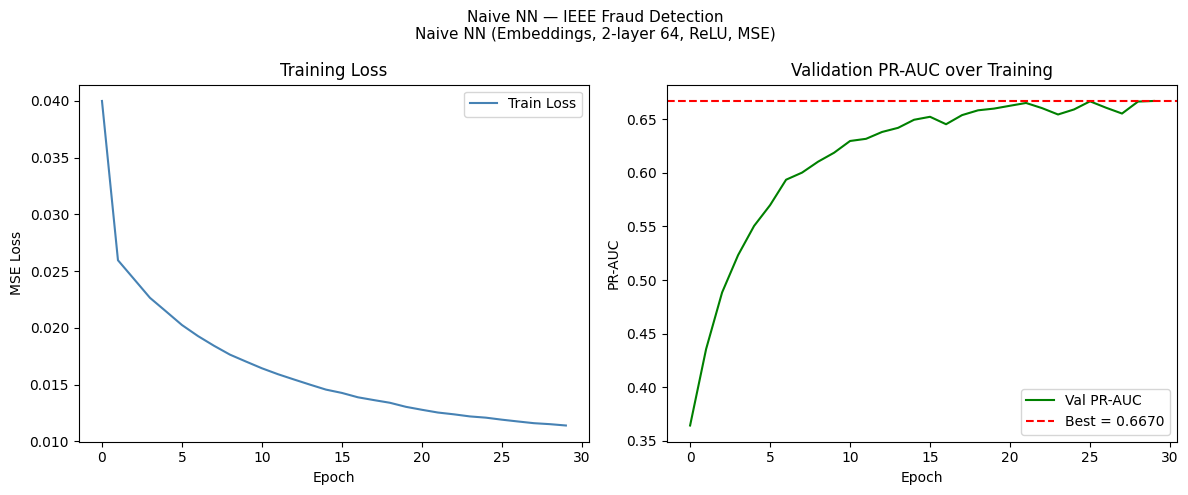

Training curves saved to model_outputs\20260405_233502_Naive_NN_(Embeddings,_2-layer_64,_ReLU,_MSE)\naive_nn_training_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(history['train_loss'], label='Train Loss', color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Training Loss')
ax.legend()

ax = axes[1]
ax.plot(history['val_pr'], label='Val PR-AUC', color='green')
ax.axhline(y=best_val_pr_auc, color='red', linestyle='--', label=f'Best = {best_val_pr_auc:.4f}')
ax.set_xlabel('Epoch')
ax.set_ylabel('PR-AUC')
ax.set_title('Validation PR-AUC over Training')
ax.legend()

plt.suptitle(f'Naive NN — IEEE Fraud Detection\n{RUN_NAME}', fontsize=11)
plt.tight_layout()
curves_path = os.path.join(RUN_DIR, 'naive_nn_training_curves.png')
plt.savefig(curves_path, dpi=150)
plt.show()
print(f"Training curves saved to {curves_path}")

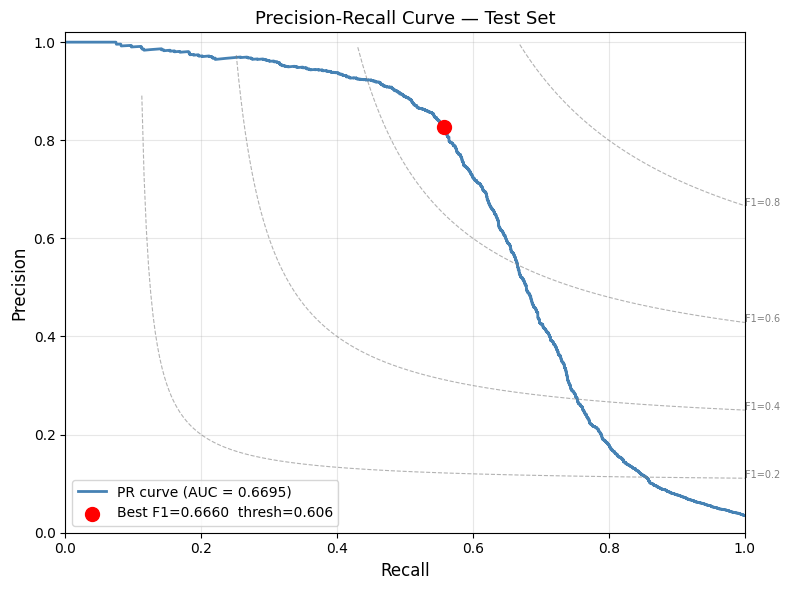

PR curve saved to model_outputs\20260405_233502_Naive_NN_(Embeddings,_2-layer_64,_ReLU,_MSE)\pr_curve.png


In [11]:
## PR Curve + best threshold based on F1

y_true, y_proba = get_predictions(model, test_loader)

precision_pts, recall_pts, thresholds = precision_recall_curve(y_true, y_proba)

f1_scores   = (2 * precision_pts[:-1] * recall_pts[:-1]
               / (precision_pts[:-1] + recall_pts[:-1] + 1e-8))
best_idx    = np.argmax(f1_scores)
best_thresh = float(thresholds[best_idx])
best_f1     = float(f1_scores[best_idx])

best_recall    = float(recall_pts[best_idx])
best_precision = float(precision_pts[best_idx])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall_pts, precision_pts, color='steelblue', lw=2,
        label=f'PR curve (AUC = {test_pr:.4f})')
ax.scatter(best_recall, best_precision, color='red', zorder=5, s=100,
           label=f'Best F1={best_f1:.4f}  thresh={best_thresh:.3f}')

for f1_iso in [0.2, 0.4, 0.6, 0.8]:
    r_vals = np.linspace(0.01, 1.0, 300)
    p_vals = f1_iso * r_vals / (2 * r_vals - f1_iso + 1e-8)
    mask   = (p_vals >= 0) & (p_vals <= 1)
    ax.plot(r_vals[mask], p_vals[mask], '--', color='grey', lw=0.8, alpha=0.6)
    ax.annotate(f'F1={f1_iso}', xy=(r_vals[mask][-1], p_vals[mask][-1]),
                fontsize=7, color='grey')

ax.set_xlabel('Recall',    fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve — Test Set', fontsize=13)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
pr_curve_path = os.path.join(RUN_DIR, 'pr_curve.png')
plt.savefig(pr_curve_path, dpi=150)
plt.show()
print(f"PR curve saved to {pr_curve_path}")

In [12]:
val_y_true, val_proba = get_predictions(model, val_loader)
val_recall  = recall_score(val_y_true,
                           (val_proba  >= best_thresh).astype(int),
                           zero_division=0)
test_recall = best_recall

print(f"\n{'='*50}")
print(f"  Final Results at best threshold = {best_thresh:.3f}")
print(f"{'='*50}")
print(f"  Test PR-AUC   : {test_pr:.4f}")
print(f"  Test F1       : {best_f1:.4f}")
print(f"  Test Recall   : {test_recall:.4f}")
print(f"  Test Precision: {best_precision:.4f}")
print(f"  Val  Recall   : {val_recall:.4f}")

final_metrics = {
    'run_name'       : RUN_NAME,
    'val_pr_auc'     : val_pr,
    'test_pr_auc'    : test_pr,
    'best_thresh'    : best_thresh,
    'test_f1'        : best_f1,
    'test_recall'    : test_recall,
    'test_precision' : best_precision,
    'val_recall'     : val_recall,
}
metrics_path = os.path.join(RUN_DIR, 'final_metrics.json')
with open(metrics_path, 'w') as f:
    _json.dump(final_metrics, f, indent=2)
print(f"\nFinal metrics saved to {metrics_path}")


  Final Results at best threshold = 0.606
  Test PR-AUC   : 0.6695
  Test F1       : 0.6660
  Test Recall   : 0.5579
  Test Precision: 0.8261
  Val  Recall   : 0.5499

Final metrics saved to model_outputs\20260405_233502_Naive_NN_(Embeddings,_2-layer_64,_ReLU,_MSE)\final_metrics.json


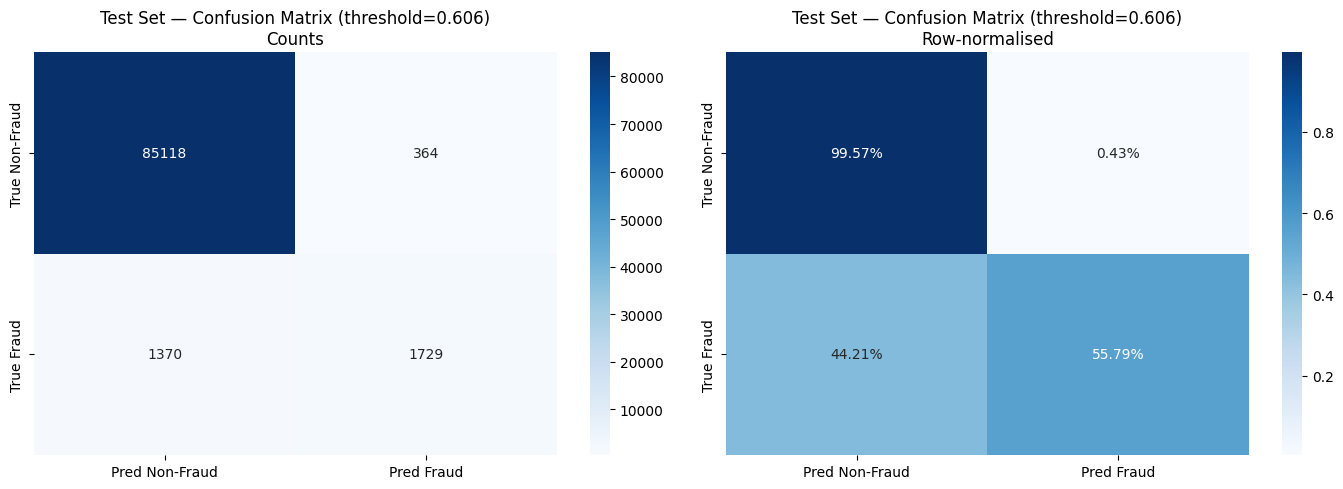


Classification Report (threshold=0.606):
              precision    recall  f1-score   support

   Non-Fraud       0.98      1.00      0.99     85482
       Fraud       0.83      0.56      0.67      3099

    accuracy                           0.98     88581
   macro avg       0.91      0.78      0.83     88581
weighted avg       0.98      0.98      0.98     88581

Confusion matrix saved to model_outputs\20260405_233502_Naive_NN_(Embeddings,_2-layer_64,_ReLU,_MSE)\confusion_matrix.png


In [13]:
plot_confusion_matrix(y_true, y_proba, threshold=best_thresh, save_dir=RUN_DIR)

## 11. Save Model

In [ ]:
model_path = os.path.join(RUN_DIR, 'naive_nn_model.pt')
torch.save({
    'model_state_dict' : best_state,
    'run_name'         : RUN_NAME,
    'num_numerical'    : len(num_cols),
    'cat_cols'         : cat_cols,
    'num_cols'         : num_cols,
    'vocab_sizes'      : vocab_sizes,
    'val_pr_auc'       : val_pr,
    'test_pr_auc'      : test_pr,
    'best_thresh'      : best_thresh,
    'test_recall'      : test_recall,
    'val_recall'       : val_recall,
}, model_path)
print(f"Model saved to {model_path}")

print(f"\n{'='*50}")
print(f"  All outputs saved to: {RUN_DIR}/")
print(f"    naive_nn_training_curves.png")
print(f"    pr_curve.png")
print(f"    confusion_matrix.png")
print(f"    classification_report.txt")
print(f"    training_log.csv")
print(f"    final_metrics.json")
print(f"    naive_nn_model.pt")
print(f"{'='*50}")